In [106]:
library(mclust)
library(cluster)
library(ggplot2)
library(factoextra)
library(fastDummies)

In [107]:
options(repr.plot.width = 25, repr.plot.height = 25) 

**Ejercicio 1:**

a) Explique como funciona el método Mclust, describa los principales parámetros de entrada y salida.

b) Utilice Mclust sin definir el número de grupos y considere el Criterio de información Bayesiano (BIC) para decidir el número de grupos óptimo. 

c) Interprete y comente los resultados obtenidos. Compare  sus resultados con aquellos obtenidos con k-means.

**Ejercicio 2:** 

a) Estudie las medidas de calidad propuestas en Murphy, Capítulo 25: purity, rand index y mutual information (pdf en siveducMD) y resuma brevemente en que consisten.

Considere el archivo "semillas.txt" que contiene una séptima variable con la clasificación de las semillas en tres variedades: 
- 1: Kama
- 2: Rosa
- 3: Canadian

b) Calcule alguna de las medidas de calidad estudiadas para los agrupamientos obtenidos con KMeans (tarea anterior) y GMM, considerando la etiqueta en V7 para sus cálculos. Compare y discuta sus resultados.

**Ejercicio 3:** 

a) Realice el análisis de agrupamiento de los datos asignados a su grupo utilizando GMM.

b) Interprete sus resultados y compare con los obtenidos con k-means.

   distancia          tiempo          velocidad         modo_transporte_bus
 Min.   : 0.020   Min.   :0.05733   Min.   :  0.01573   Min.   :0.0000     
 1st Qu.: 8.675   1st Qu.:0.53700   1st Qu.: 12.12287   1st Qu.:0.0000     
 Median :15.615   Median :0.78542   Median : 18.95680   Median :0.0000     
 Mean   :16.820   Mean   :0.84357   Mean   : 26.45919   Mean   :0.3302     
 3rd Qu.:22.878   3rd Qu.:1.04221   3rd Qu.: 31.72714   3rd Qu.:1.0000     
 Max.   :77.310   Max.   :4.23100   Max.   :157.50000   Max.   :1.0000     
 modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
 Min.   :0.0000            Min.   :0.0000       Min.   :0.0000         
 1st Qu.:0.0000            1st Qu.:0.0000       1st Qu.:0.0000         
 Median :0.0000            Median :0.0000       Median :0.0000         
 Mean   :0.3767            Mean   :0.1047       Mean   :0.1512         
 3rd Qu.:1.0000            3rd Qu.:0.0000       3rd Qu.:0.0000         
 Max.   :1.0000            Max.   :1

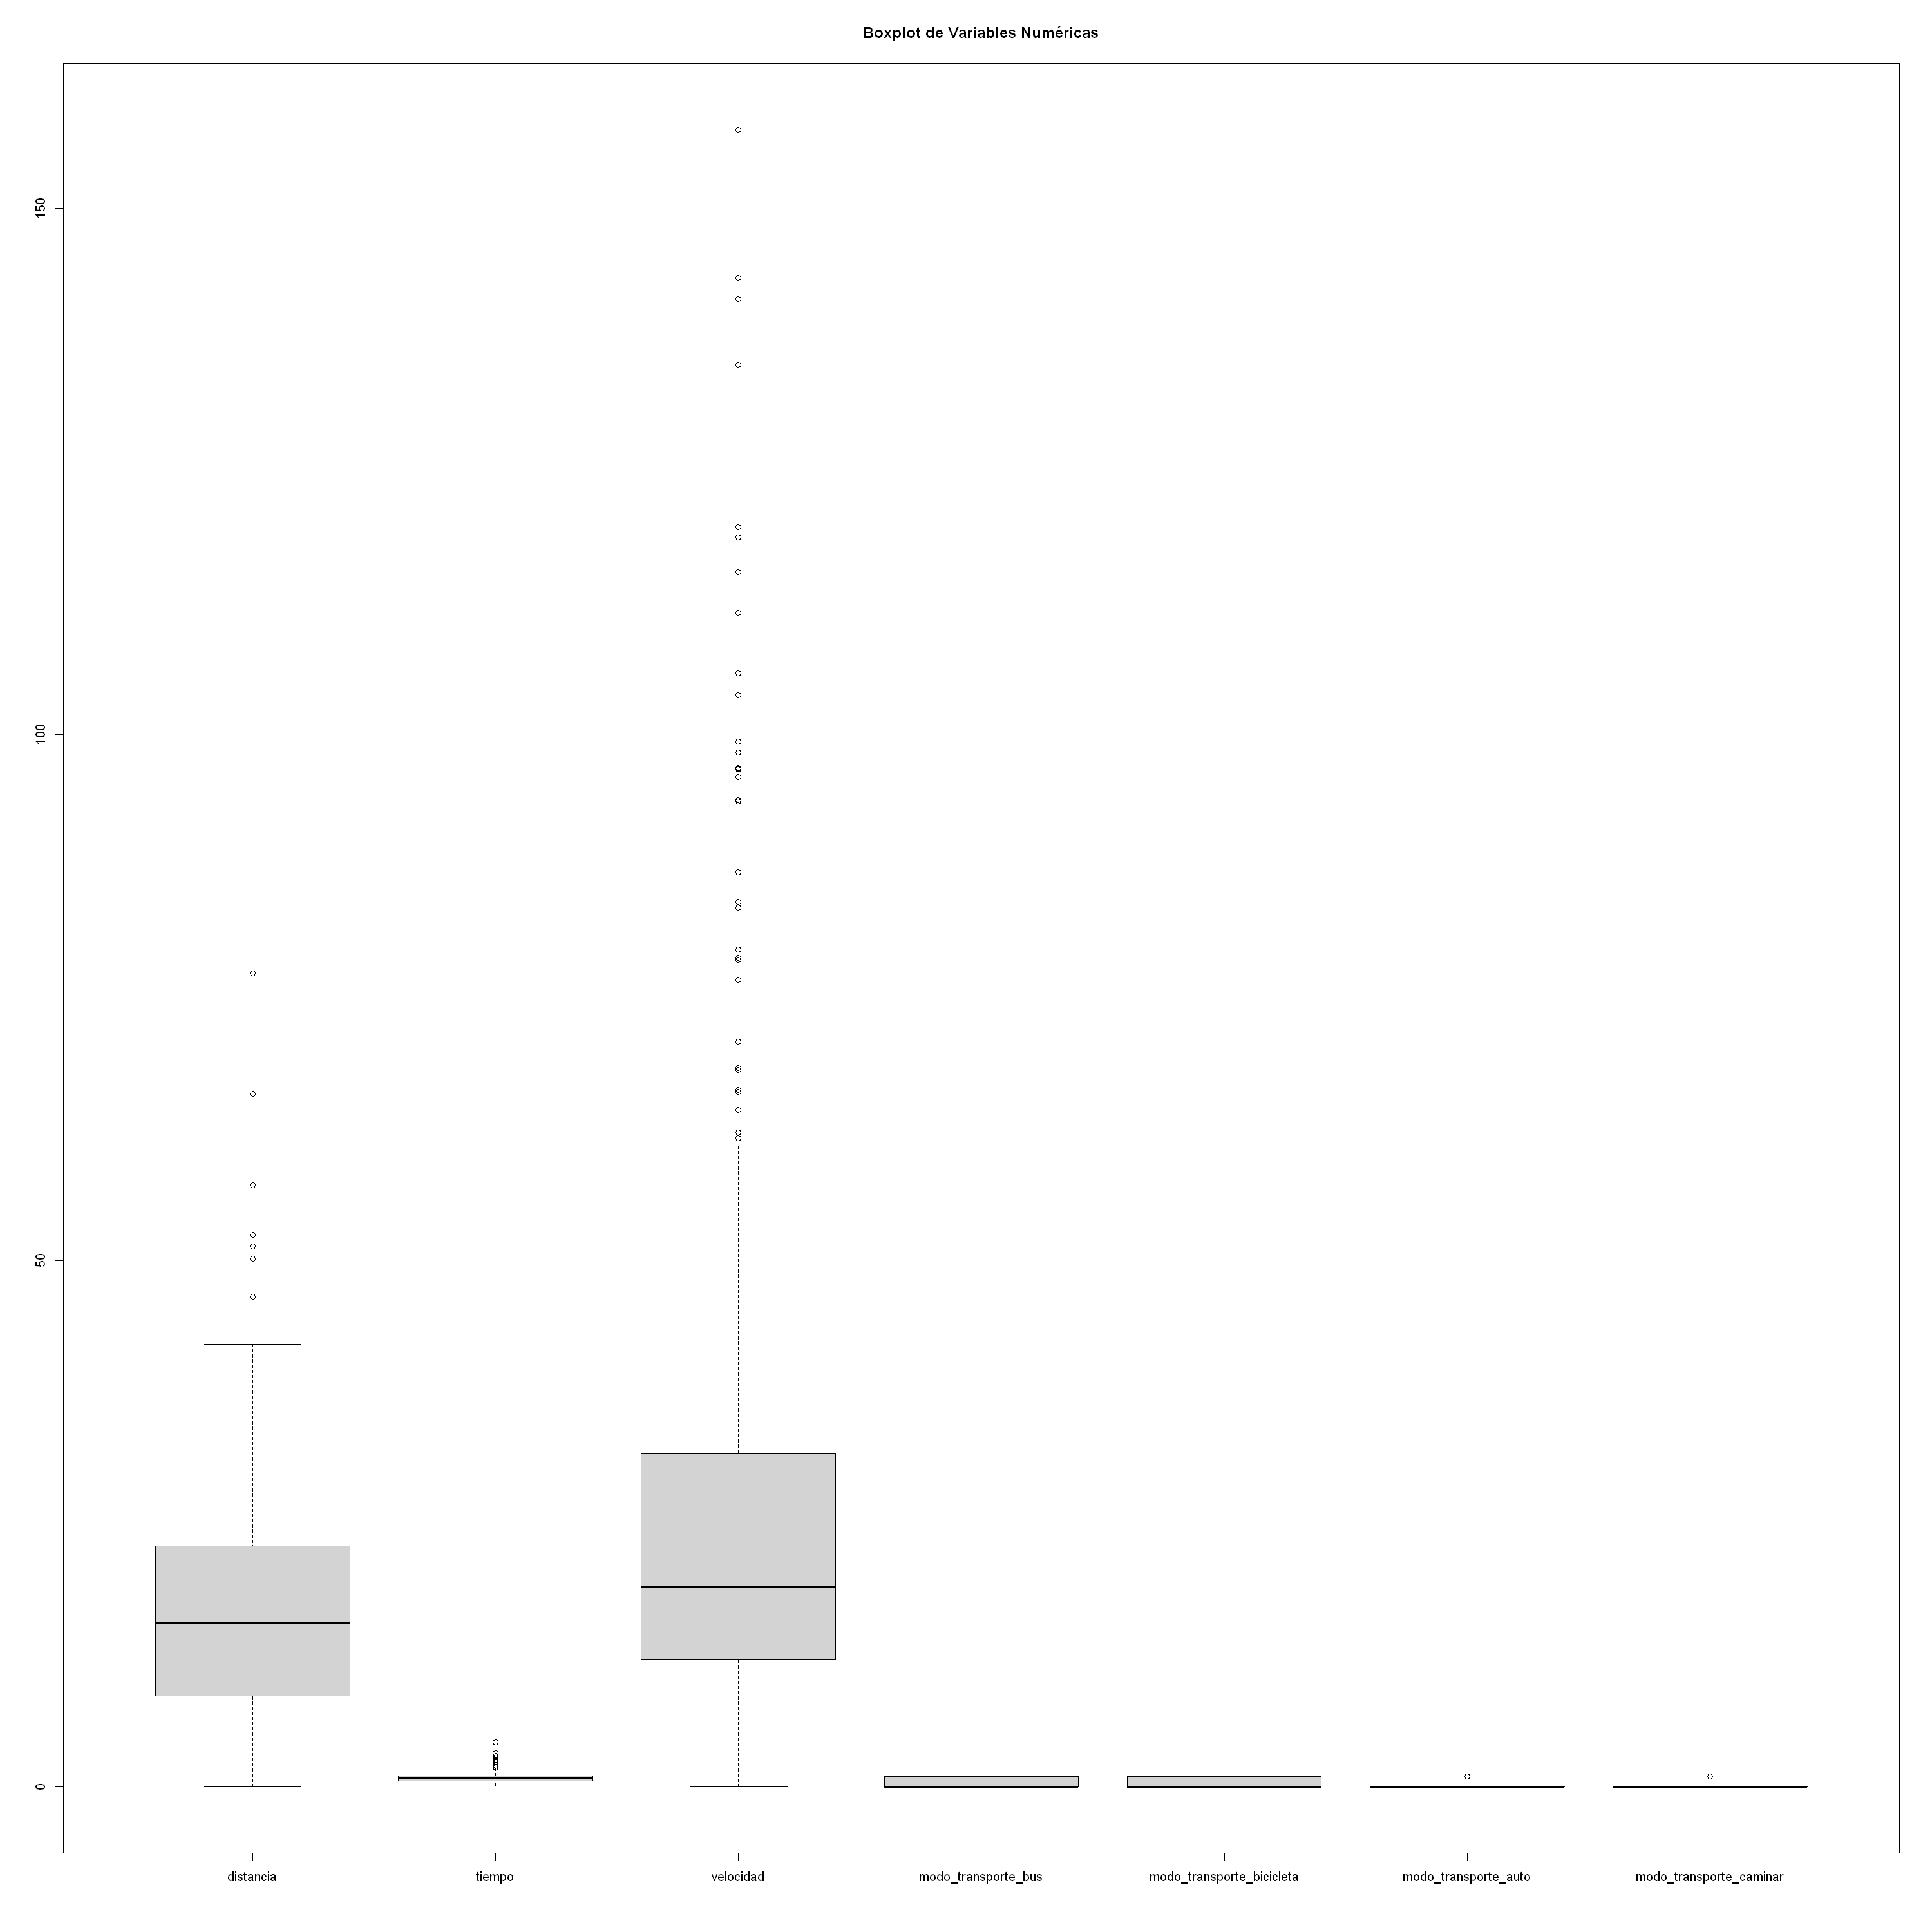

In [108]:
# Se cargan los datos originales
datos_grupo <- read.csv("..//datasets_simulados//Grupo10.csv", dec=".", sep=",")

datos_grupo <- dummy_cols(datos_grupo, select_columns = "modo_transporte", remove_selected_columns = FALSE)

# Se filtran valores negativos y nulos (Ya que no tienen sentido logico)
datos_grupo <- datos_grupo[datos_grupo$distancia > 0 & datos_grupo$tiempo > 0 & datos_grupo$viajes > 0, ]
datos_grupo <- na.omit(datos_grupo)

# Agregamos velocidad (en kilometros) promedio antes de filtrar. Tambien quitamos velocidades que no tienen sentido 
# (Velocidades sobre 160 kilometros por hora, teniendo en cuenta que la velocidad maxima en chile es 120km/h en autopista y que algunos trenes efe podrian llegar a 160km/h en algunos tramos).
datos_grupo$tiempo <- datos_grupo$tiempo / 60
datos_grupo$velocidad <- datos_grupo$distancia / datos_grupo$tiempo
datos_grupo <- datos_grupo[datos_grupo$velocidad <= 160, ]

# Solo usamos los datos numericos.
datos_num <- datos_grupo[ , c("distancia", "tiempo", "velocidad", "modo_transporte_bus", "modo_transporte_bicicleta", "modo_transporte_auto", "modo_transporte_caminar")]

summary(datos_num)
boxplot(datos_num, main="Boxplot de Variables Numéricas")

In [109]:
datos_continuas <- scale(datos_grupo[, c("distancia", "tiempo", "velocidad")])

km <- kmeans(datos_continuas, centers = 4, nstart = 25)
clus <- Mclust(datos_continuas, G = 2:6)
summary(clus)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVV (ellipsoidal, varying volume, shape, and orientation) model with 6
components: 

 log-likelihood   n df       BIC       ICL
      -523.5707 430 59 -1404.905 -1440.716

Clustering table:
  1   2   3   4   5   6 
 70  34  76 134  39  77 

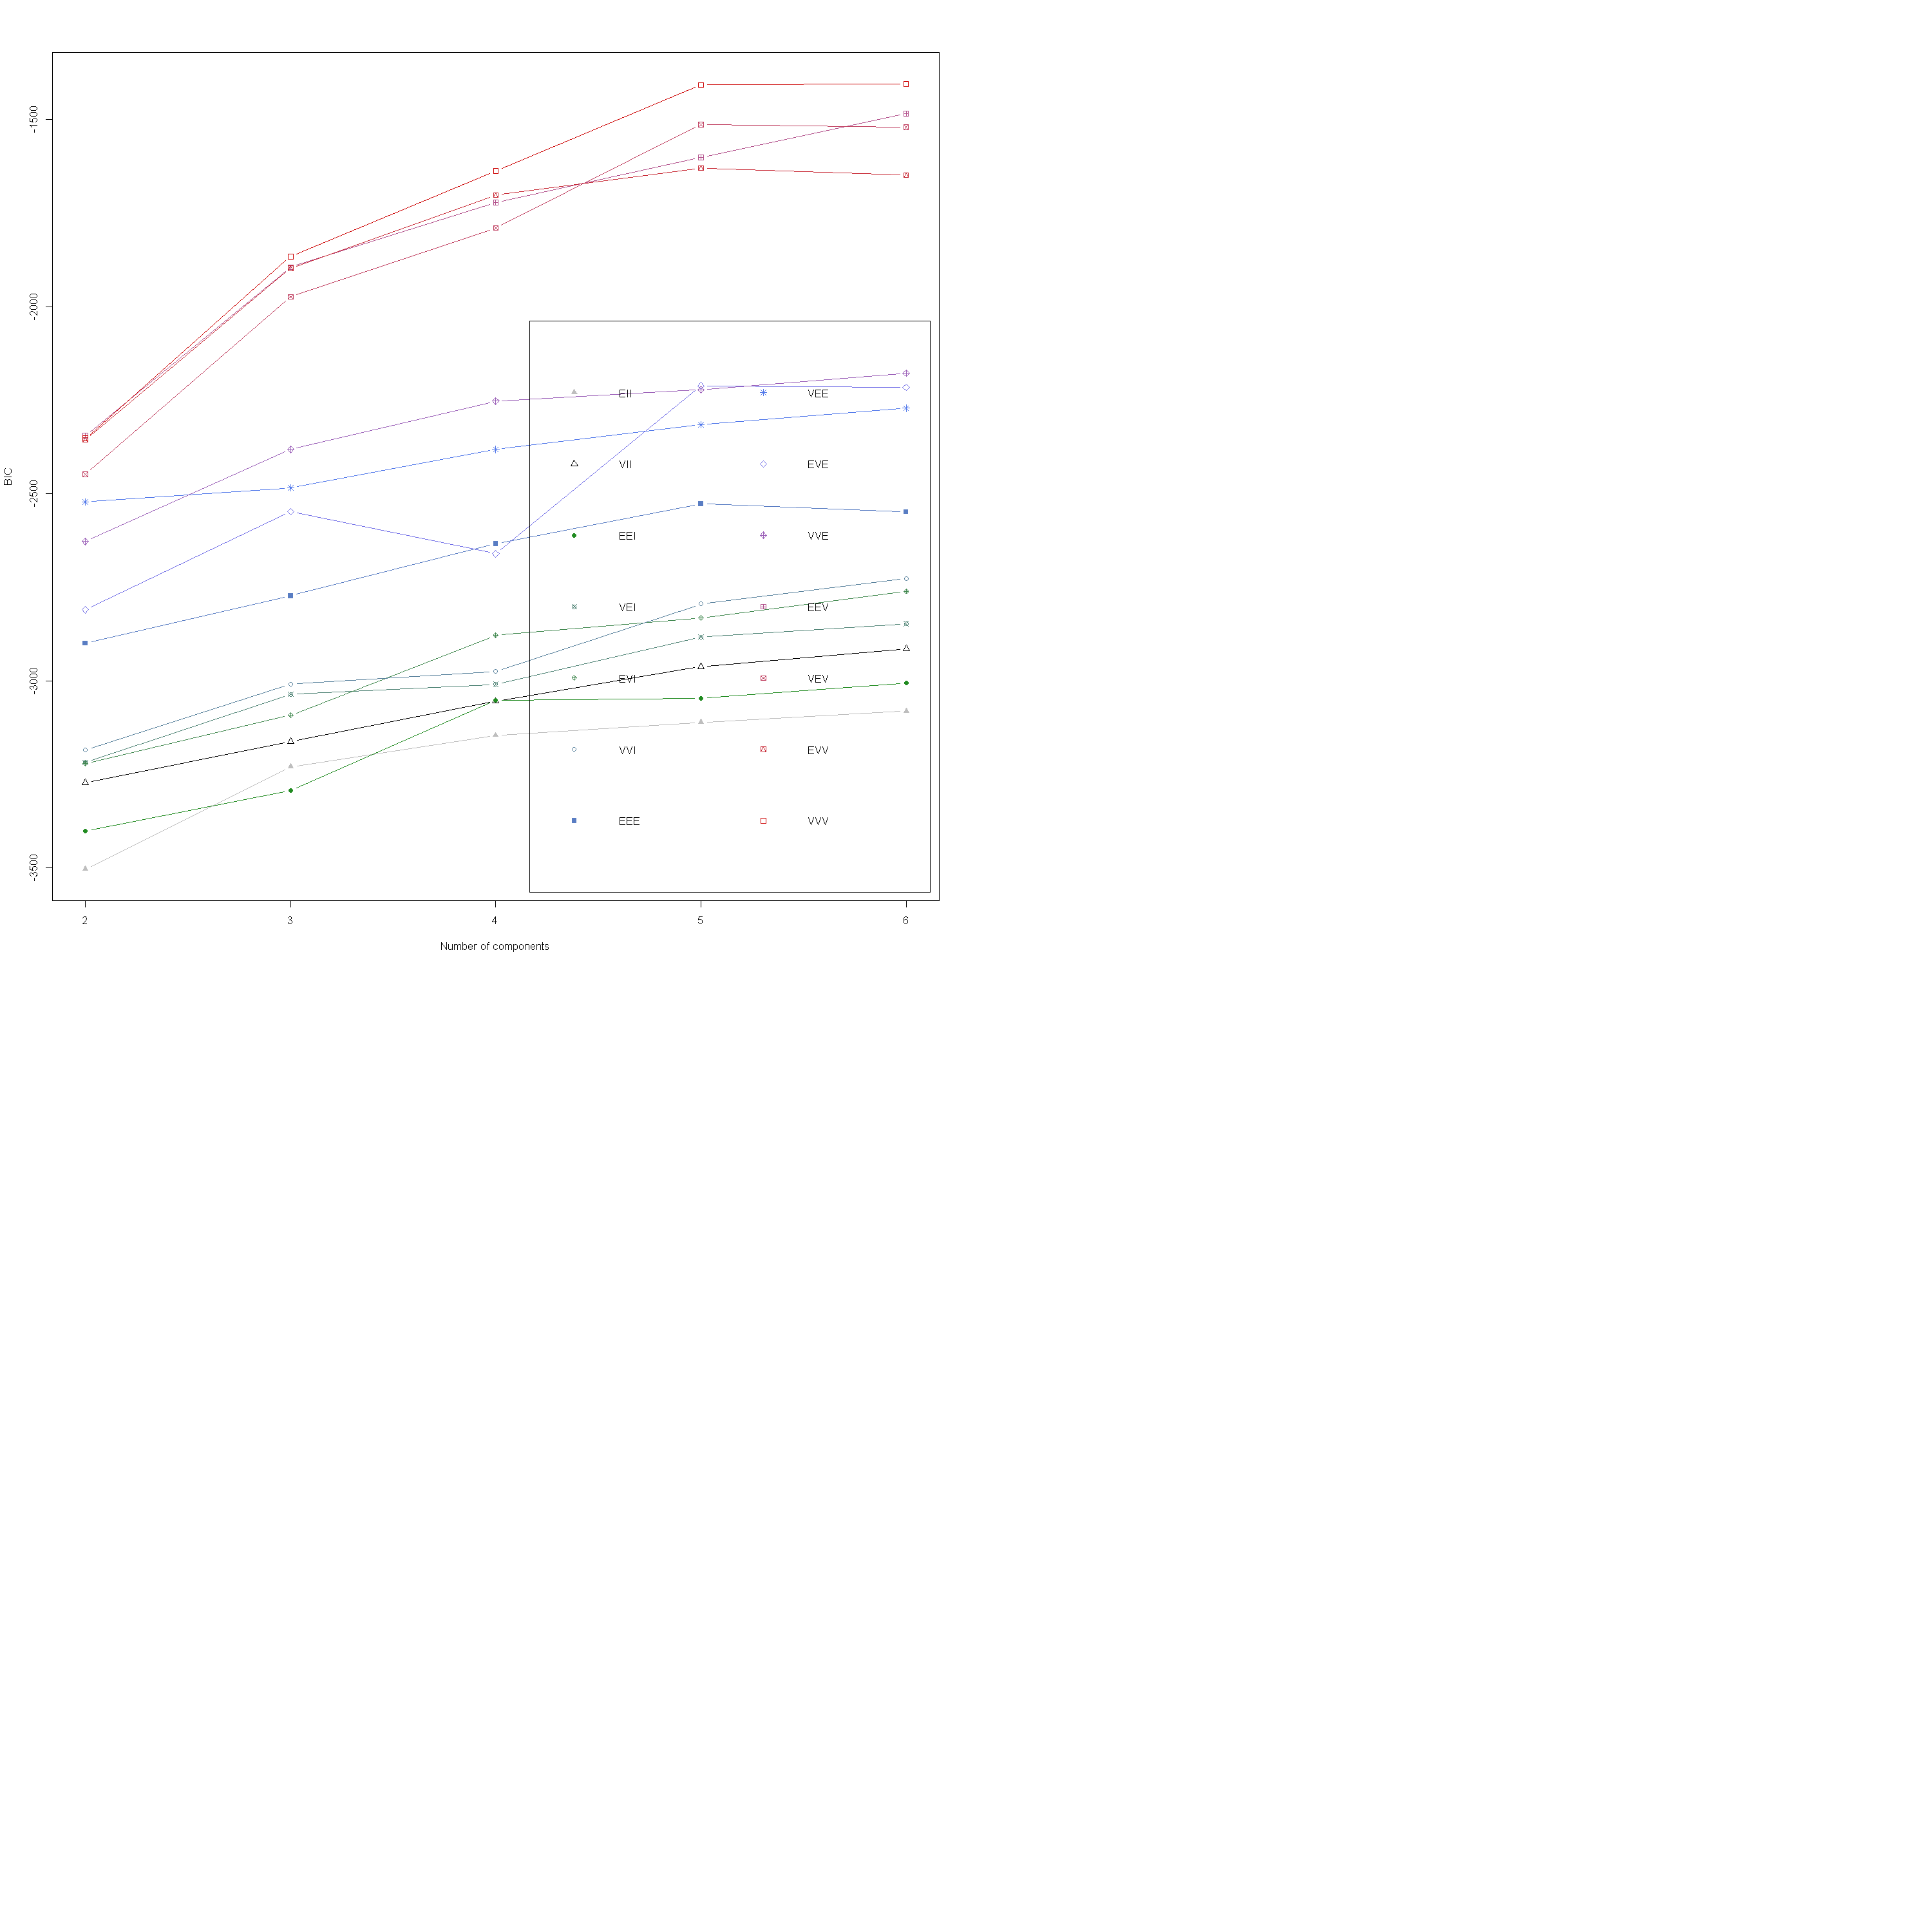

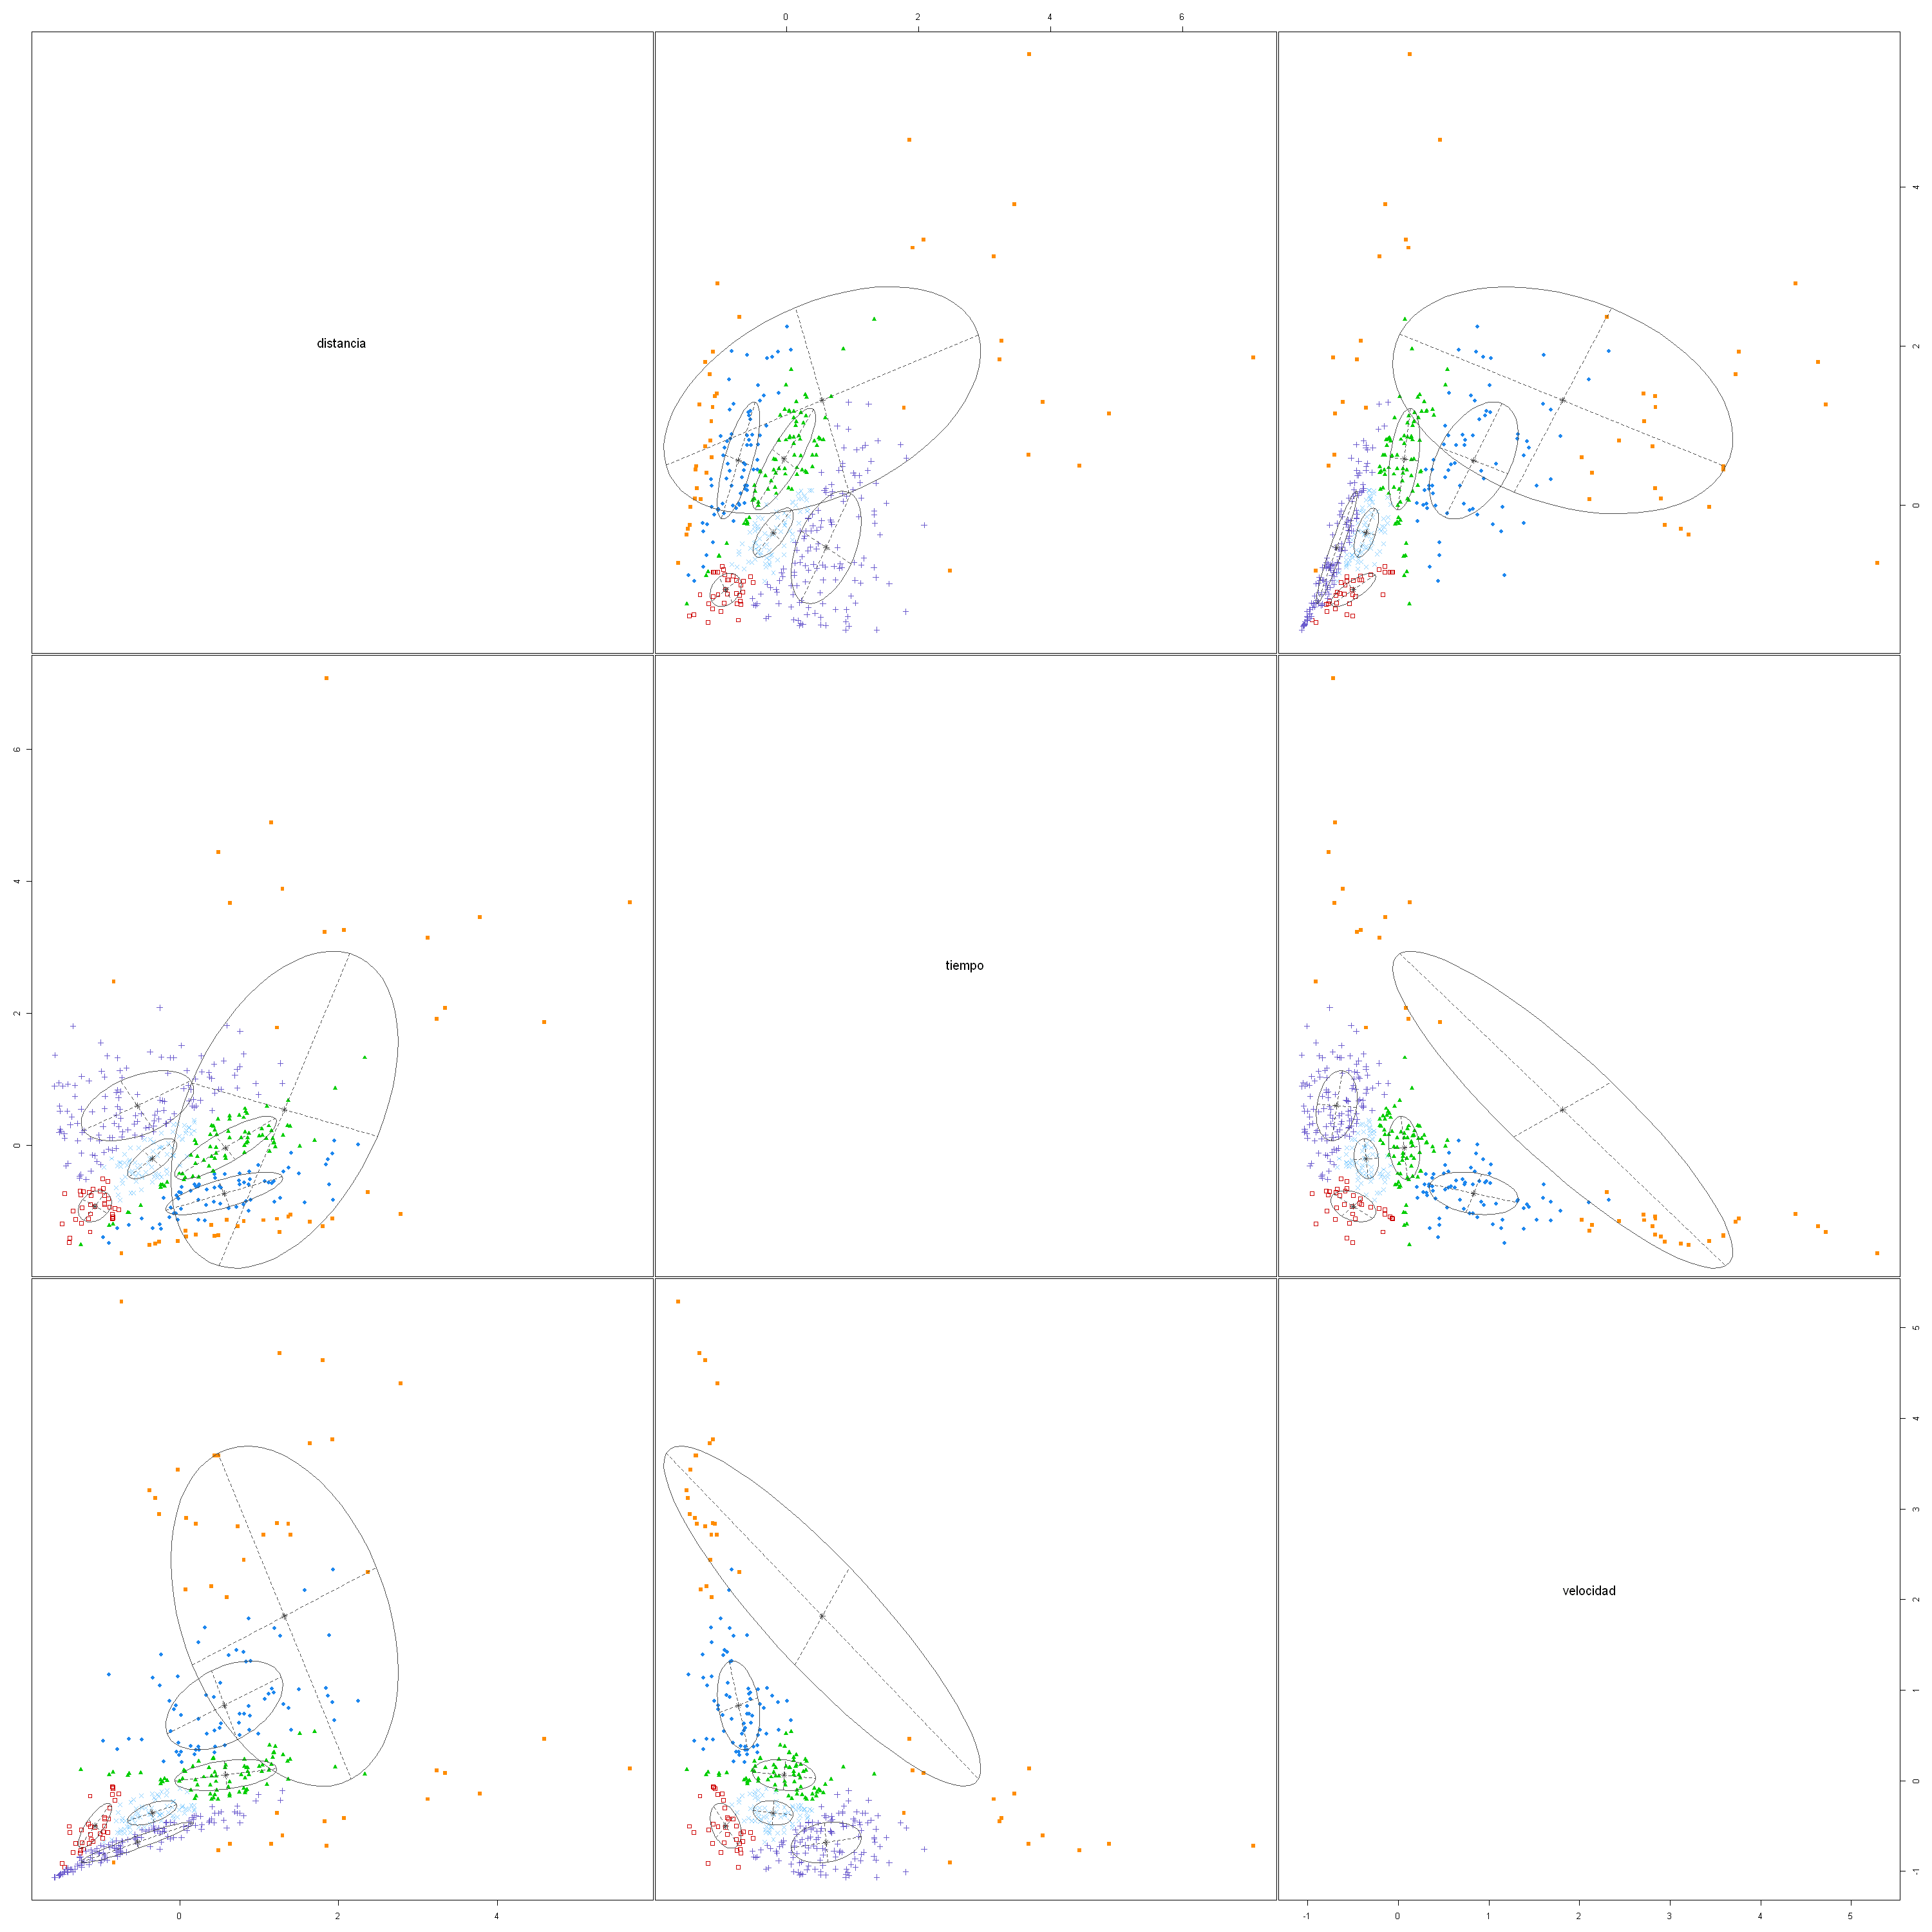

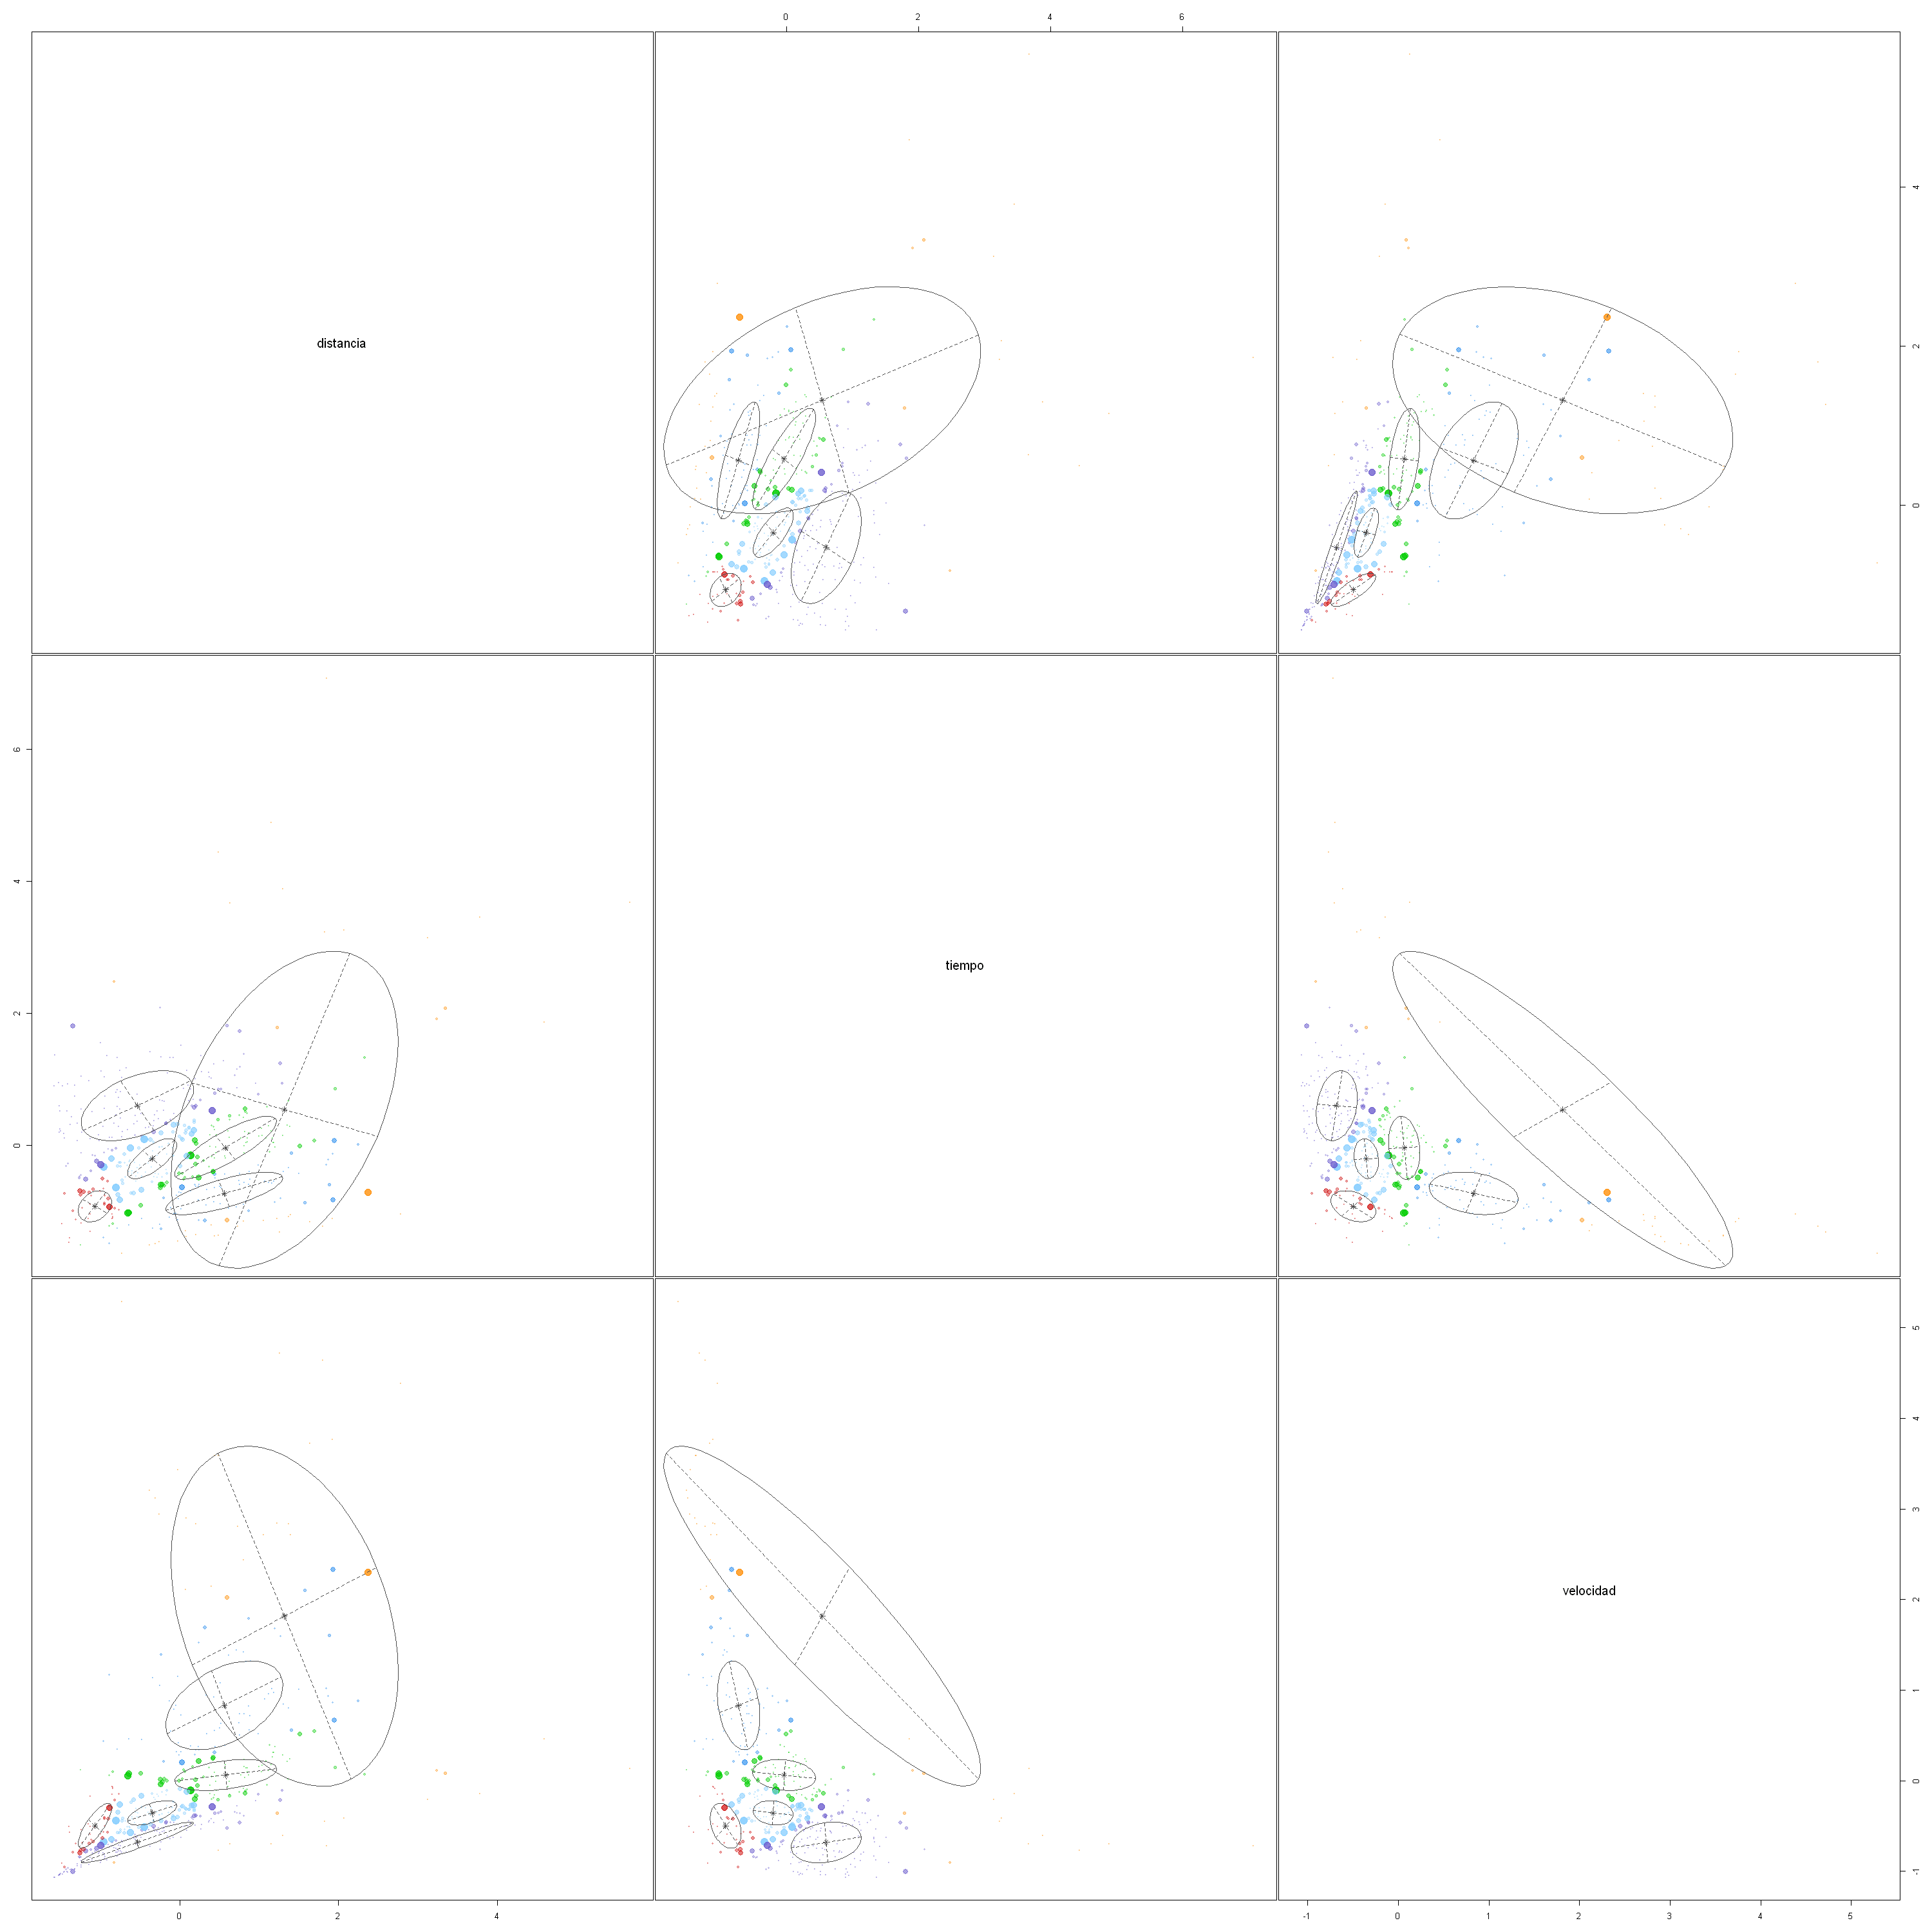

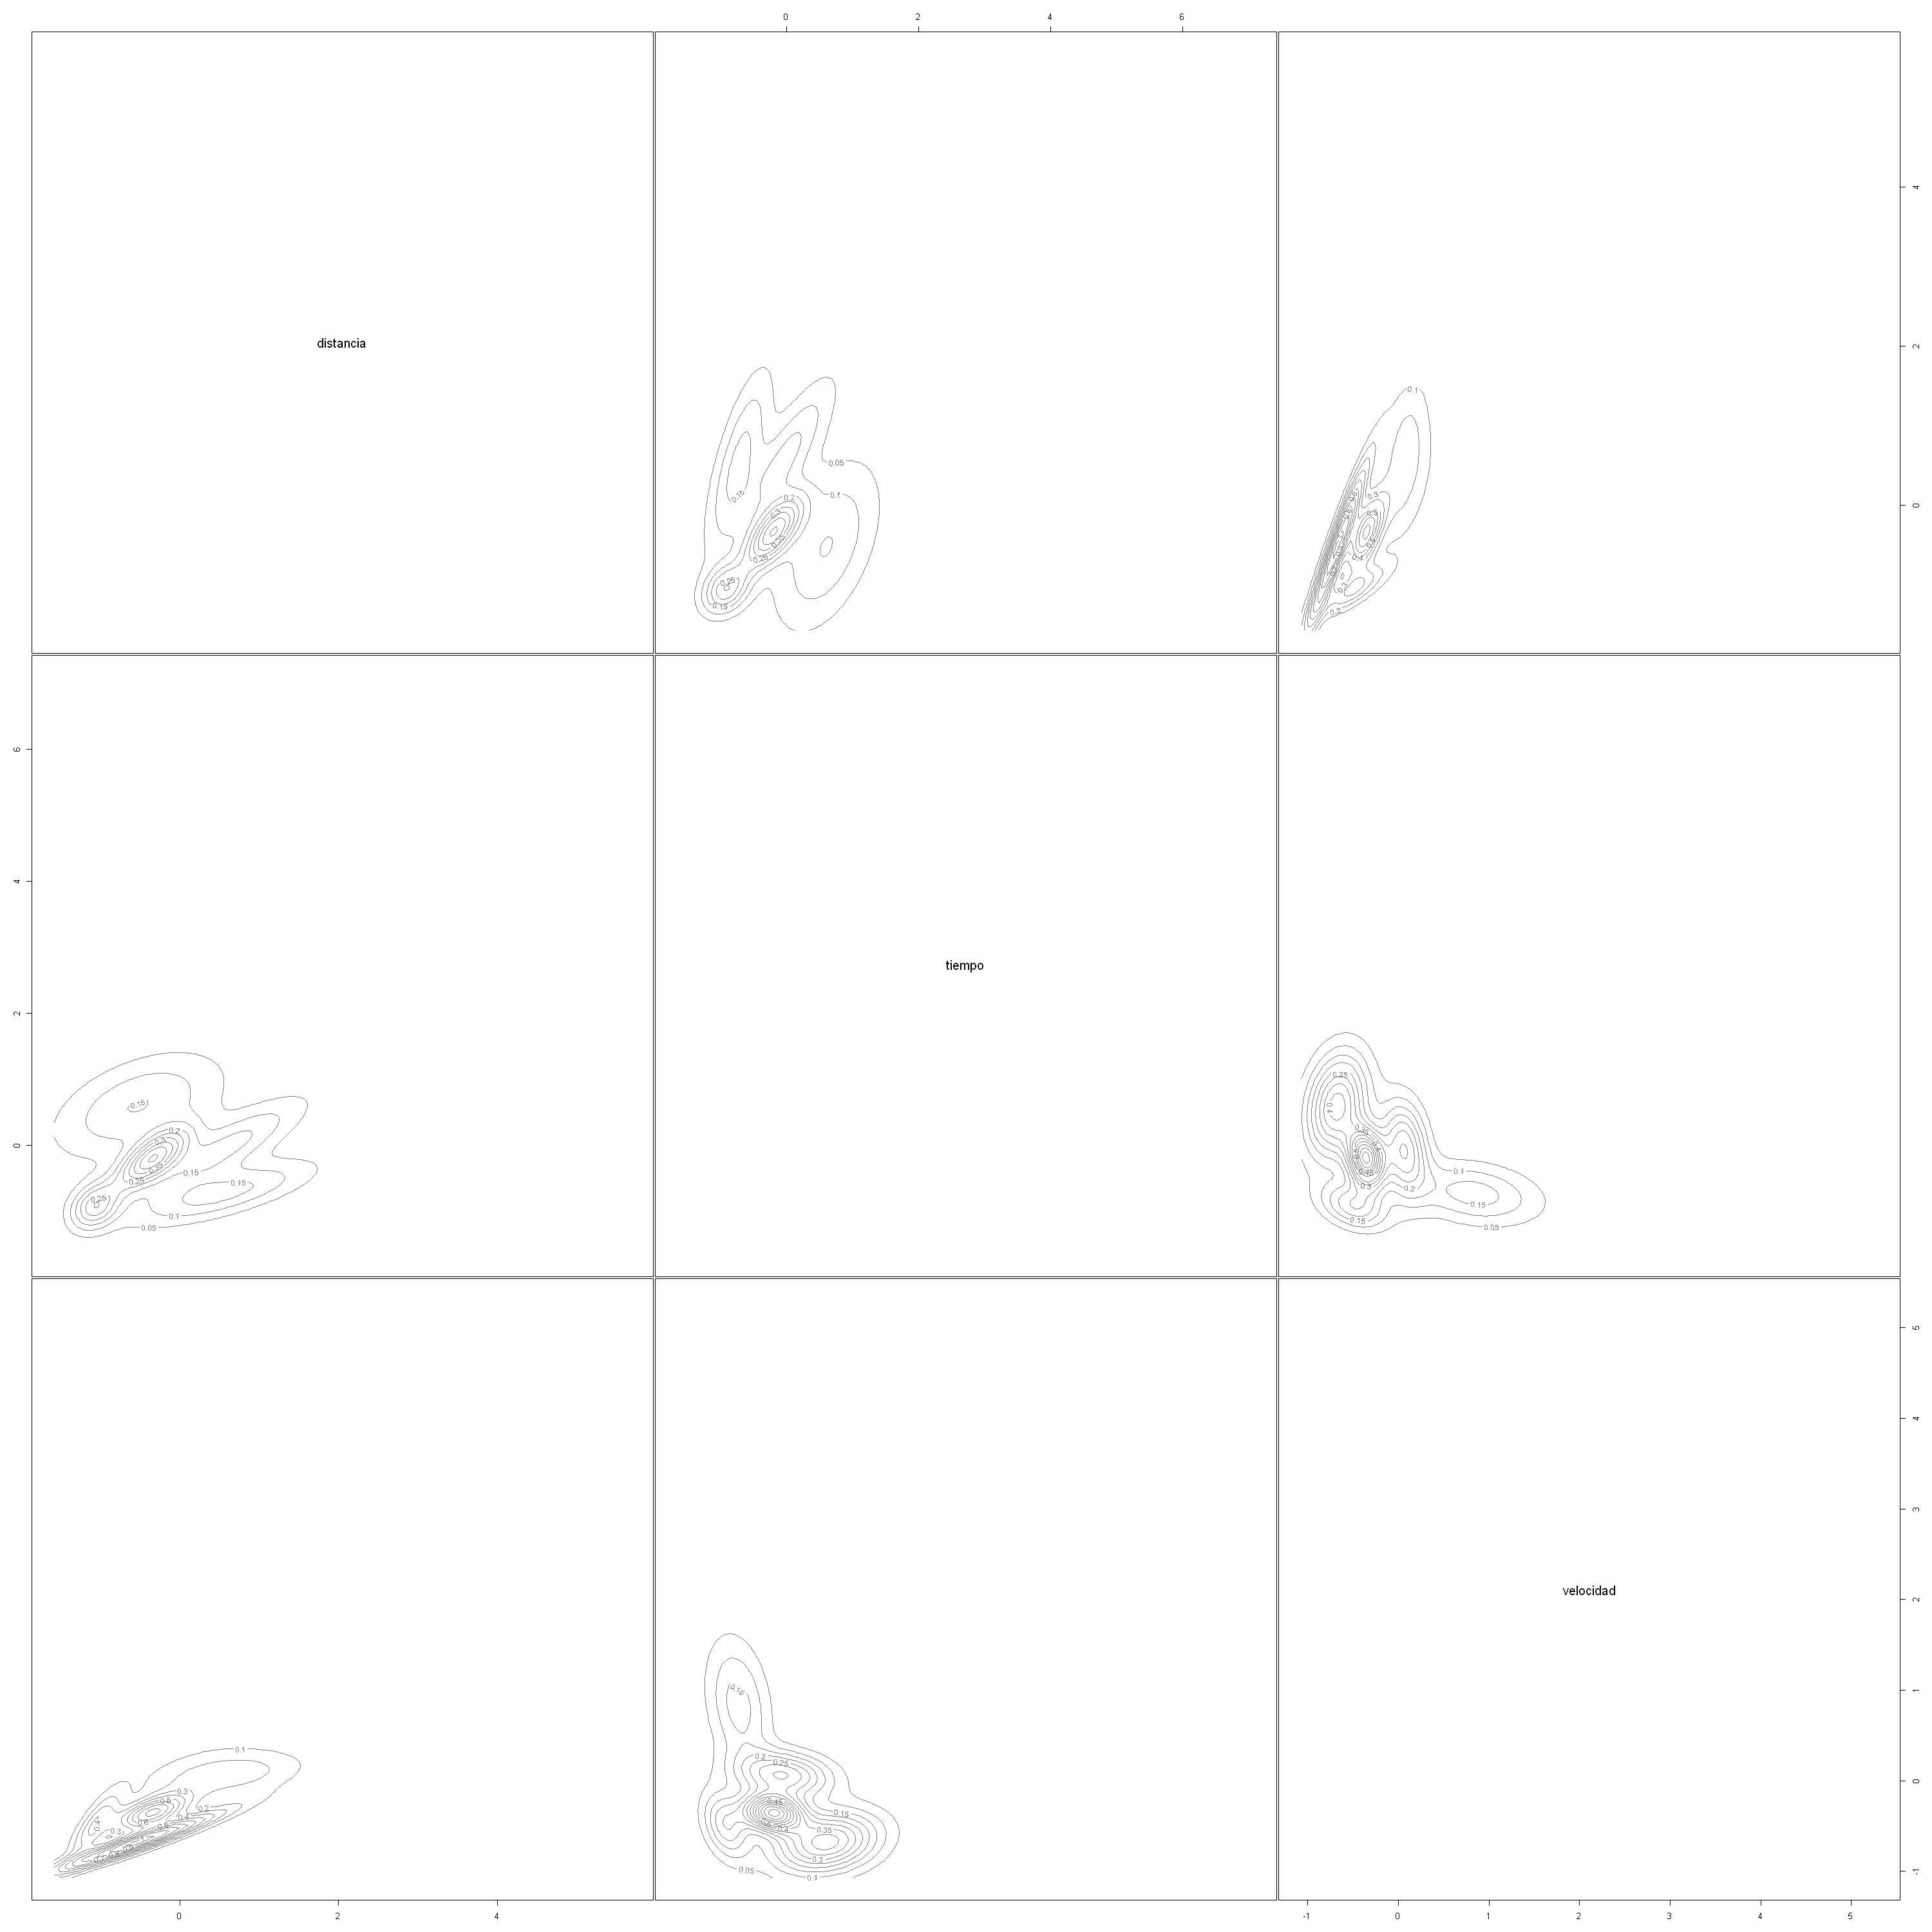

In [110]:
par(mfrow = c(2, 2))
plot(clus, what = "BIC")            # curva BIC → G óptimo
plot(clus, what = "classification") # mapa de clusters
plot(clus, what = "uncertainty")    # incertidumbre de asignación
plot(clus, what = "density")        # densidad estimada

In [111]:
cl <- clus$classification
for (g in 1:clus$G) {
  cat("\n--- Cluster", g, "(n =", sum(cl == g), ") ---\n")
  print(apply(datos_num[cl == g, ], 2, summary))
}


--- Cluster 1 (n = 70 ) ---
        distancia    tiempo velocidad modo_transporte_bus
Min.      6.56000 0.1323333  31.56048           0.0000000
1st Qu.  17.00000 0.3928333  38.07737           0.0000000
Median   22.29500 0.5068333  46.13019           0.0000000
Mean     22.99729 0.4937500  47.57368           0.4428571
3rd Qu.  28.07000 0.5820417  52.97229           1.0000000
Max.     40.78000 0.8746667  84.12580           1.0000000
        modo_transporte_bicicleta modo_transporte_auto modo_transporte_caminar
Min.                    0.0000000            0.0000000              0.00000000
1st Qu.                 0.0000000            0.0000000              0.00000000
Median                  0.0000000            0.0000000              0.00000000
Mean                    0.3142857            0.1857143              0.02857143
3rd Qu.                 1.0000000            0.0000000              0.00000000
Max.                    1.0000000            1.0000000              1.00000000

--- Cluster

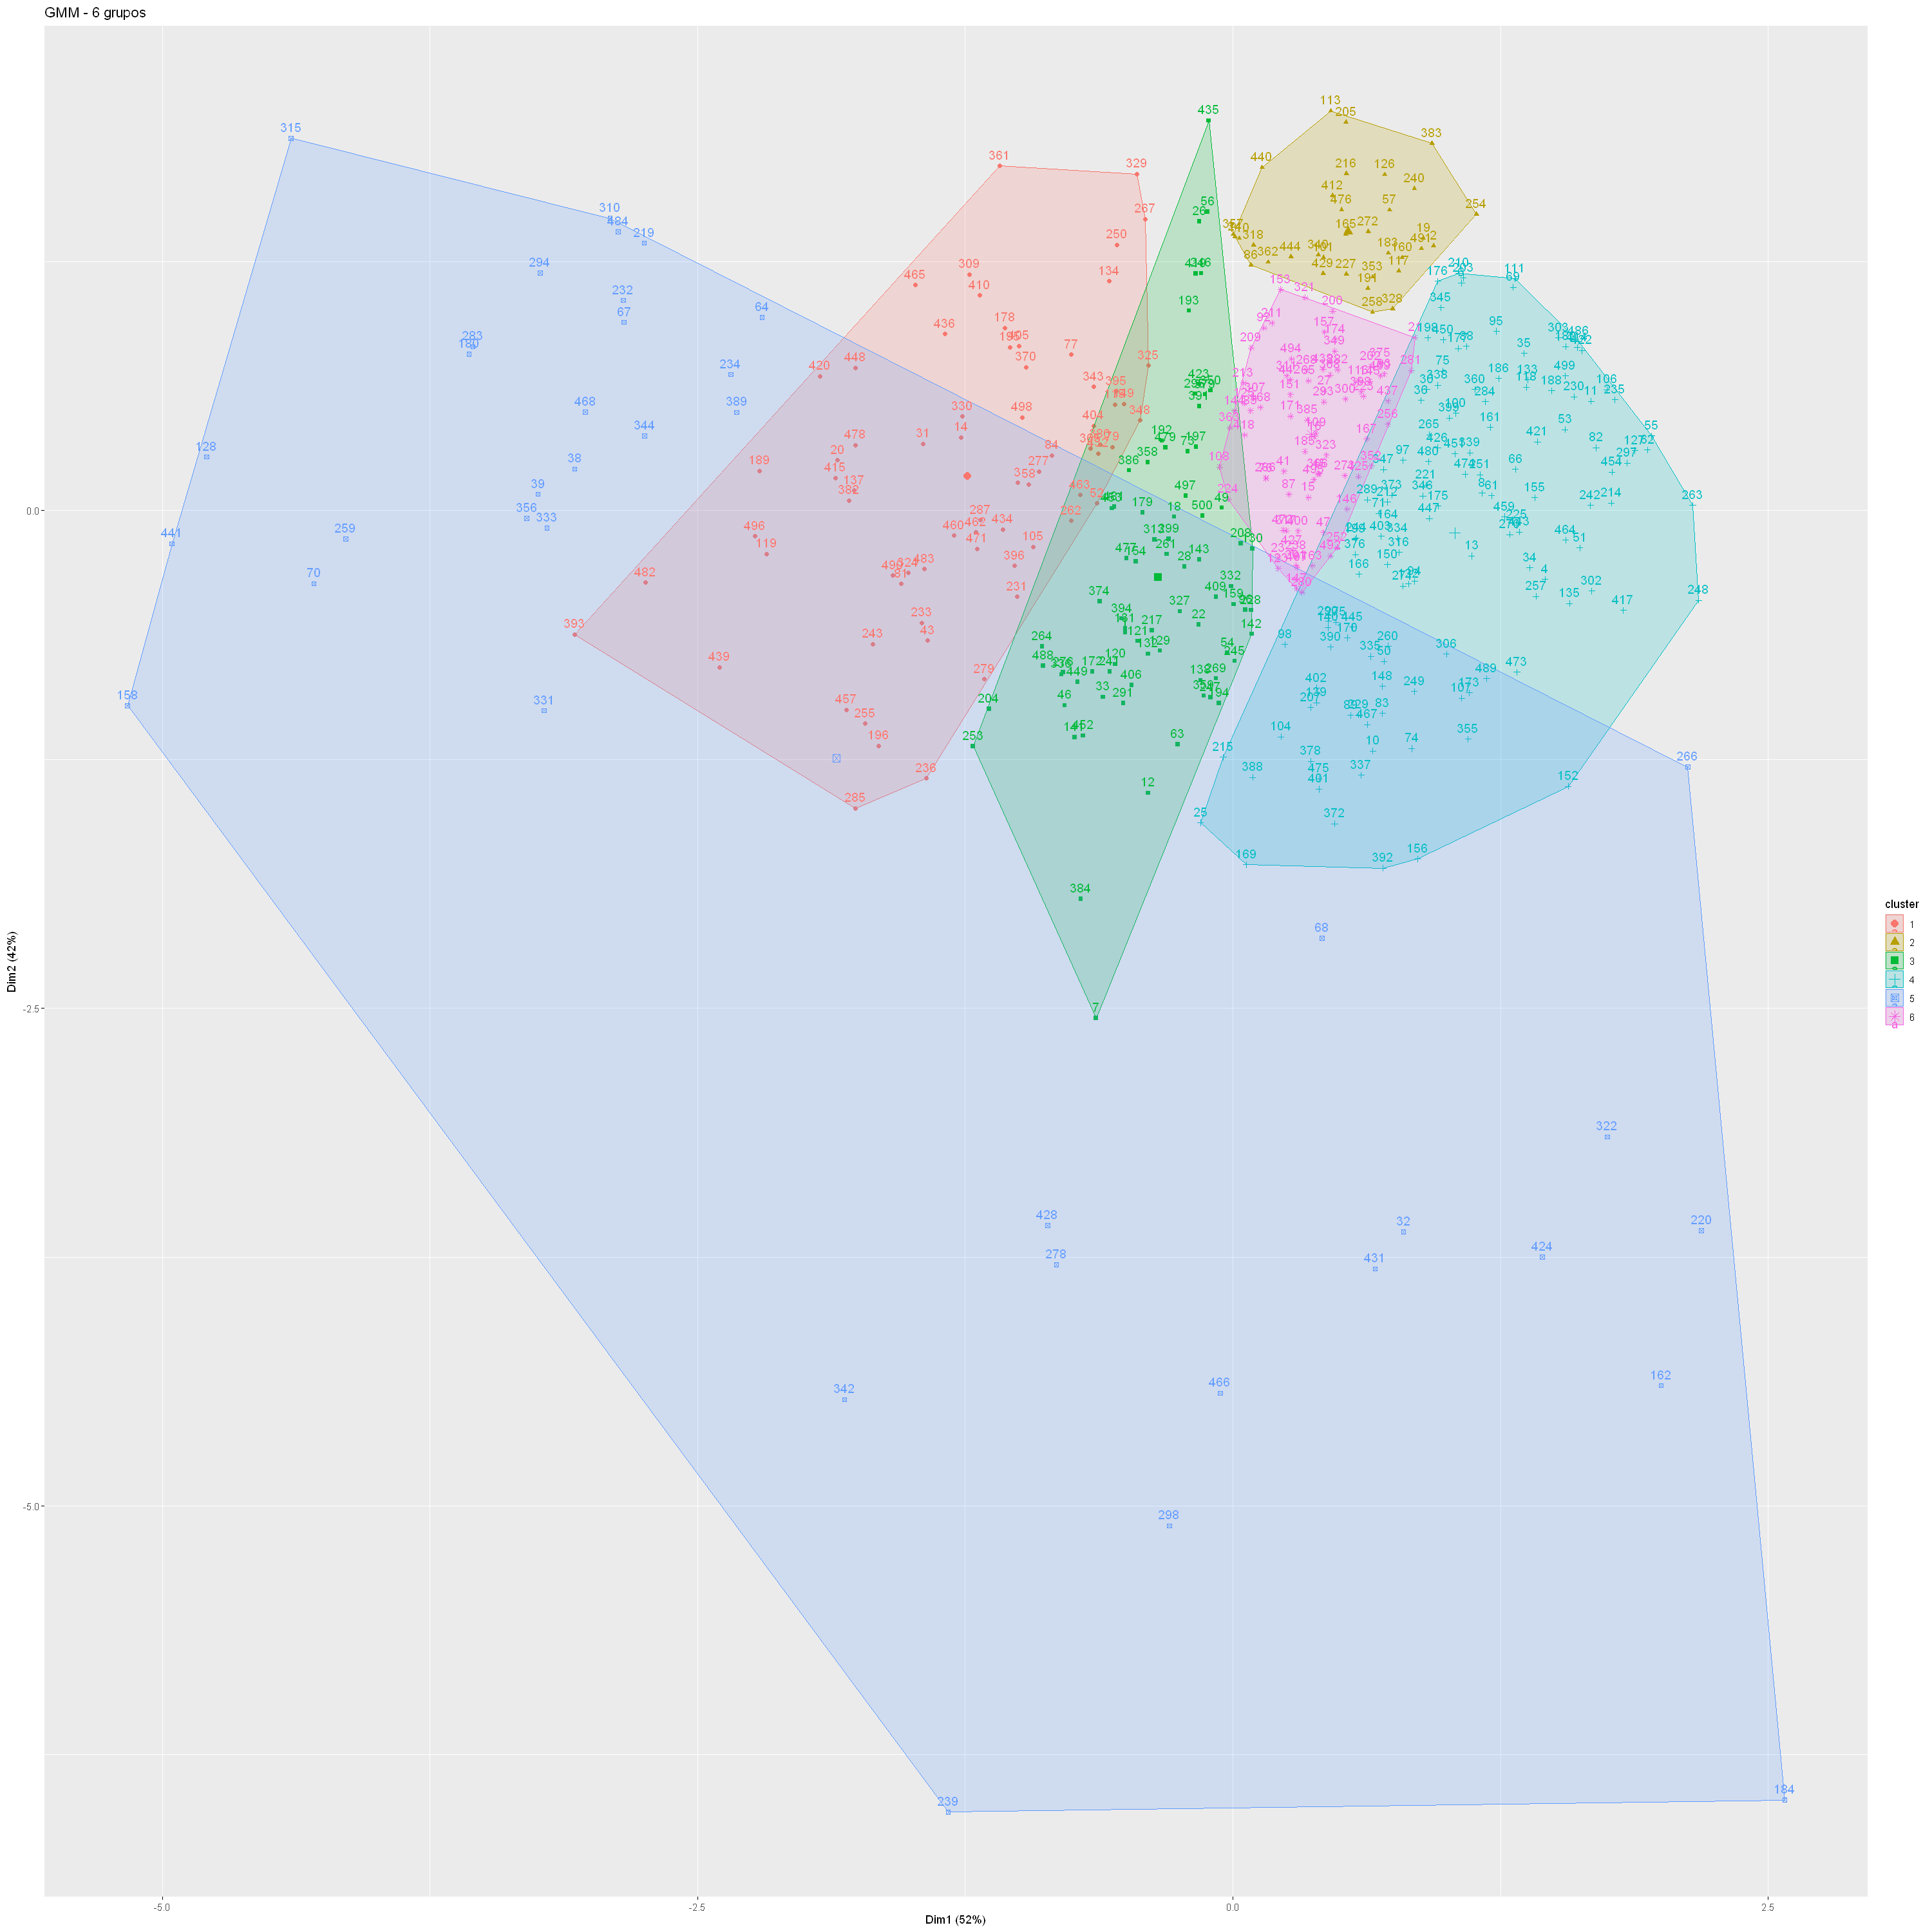

In [ ]:
set.seed(42)
km <- kmeans(datos_num, centers = clus$G, nstart = 25)

par(mfrow = c(1, 2))
fviz_cluster(clus, datos_num, main = paste("GMM -", clus$G, "grupos"))
fviz_cluster(km,   datos_num, main = paste("K-means -", clus$G, "grupos"))

In [113]:
table(GMM = clus$classification, KMeans = km$cluster)

   KMeans
GMM  1  2  3  4  5  6
  1  0  0 34  0  0 36
  2  0  0  0 24 10  0
  3  0  2  0  0 24 50
  4  0  0  0 79 52  3
  5 20  9  4  1  5  0
  6  0  0  0  9 68  0